In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow

In [3]:
cleaned_retail = pd.read_csv("../data/processed/cleaned_retail.csv")

In [4]:
forecast_df = pd.read_csv("../data/processed/hybrid_forecast.csv")

In [5]:
forecast_demand = forecast_df["hybrid_prediction"].iloc[-1]
print("Forecast Demand:", forecast_demand)

Forecast Demand: 15372.883


In [6]:
current_stock = 500
lead_time_days = 5
safety_stock = forecast_demand * 0.2
print("Safety Stock:", safety_stock)

Safety Stock: 3074.5766000000003


In [7]:
reorder_point = ((forecast_demand / 30) * lead_time_days) + safety_stock
print("Reorder Point:", reorder_point)

Reorder Point: 5636.723766666667


In [8]:
if current_stock < reorder_point:
    inventory_status = "Reorder Needed"
else:
    inventory_status = "Stock Sufficient"
print("Inventory Status:", inventory_status)

Inventory Status: Reorder Needed


In [9]:
if current_stock < reorder_point:
    recommended_order_qty = (forecast_demand+ safety_stock- current_stock)
else:
    recommended_order_qty = 0
print(
    "Recommended Order Quantity:",recommended_order_qty)

Recommended Order Quantity: 17947.459600000002


In [10]:
inventory_opt = pd.DataFrame({
    "forecast_demand":[forecast_demand],
    "current_stock":[current_stock],
    "lead_time_days":[lead_time_days],
    "safety_stock":[safety_stock],
    "reorder_point":[reorder_point],
    "inventory_status":[inventory_status],
    "recommended_order_qty":[recommended_order_qty]
})

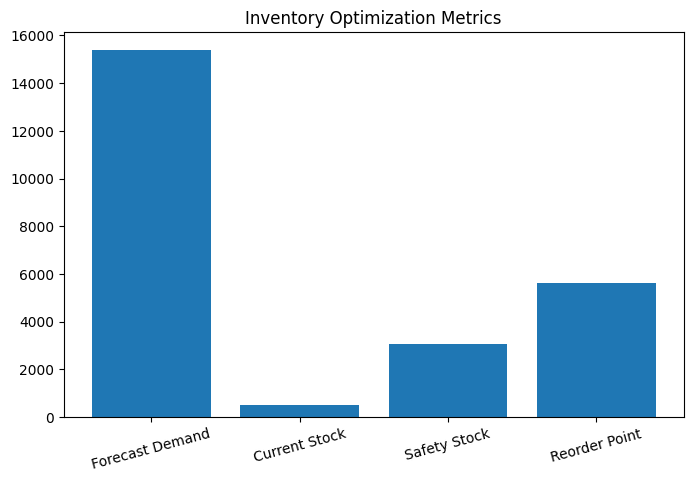

In [11]:
metrics = [forecast_demand,current_stock,safety_stock,reorder_point]
labels = ["Forecast Demand","Current Stock","Safety Stock","Reorder Point"]
plt.figure(figsize=(8,5))
plt.bar(labels, metrics)
plt.title("Inventory Optimization Metrics")
plt.xticks(rotation=15)
plt.show()

In [12]:
inventory_opt.to_csv("../data/processed/inventory_optimization.csv",index=False)

In [13]:
with mlflow.start_run(run_name="inventory_optimization"):
    mlflow.log_param("lead_time_days",lead_time_days)
    mlflow.log_metric("forecast_demand",forecast_demand)
    mlflow.log_metric("reorder_point",reorder_point)
    mlflow.log_metric("recommended_order_qty",recommended_order_qty)
    mlflow.log_artifact("../data/processed/inventory_optimization.csv")